# Sales Data EDA — Full Notebook

This notebook performs a full exploratory data analysis (Option A) on your CSV.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

%matplotlib inline

plt.style.use('default')
sns.set_theme()

In [3]:
#Loading Data

In [4]:
df = pd.read_csv("CSV Files/End term_sales_data.csv")

# Remove unnamed columns
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

print('Shape:', df.shape)
print("")
print("Coluomns: ",df.columns.tolist())
print("")
df.head()


Shape: (1000, 14)

Coluomns:  ['Product_ID', 'Sale_Date', 'Sales_Rep', 'Region', 'Sales_Amount', 'Quantity_Sold', 'Product_Category', 'Unit_Cost', 'Unit_Price', 'Customer_Type', 'Discount', 'Payment_Method', 'Sales_Channel', 'Region_and_Sales_Rep']



,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,03-02-2023,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,21-04-2023,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,21-09-2023,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,24-08-2023,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,24-03-2023,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Product_ID            1000 non-null   int64  
 1   Sale_Date             1000 non-null   object 
 2   Sales_Rep             1000 non-null   object 
 3   Region                1000 non-null   object 
 4   Sales_Amount          1000 non-null   float64
 5   Quantity_Sold         1000 non-null   int64  
 6   Product_Category      1000 non-null   object 
 7   Unit_Cost             1000 non-null   float64
 8   Unit_Price            1000 non-null   float64
 9   Customer_Type         1000 non-null   object 
 10  Discount              1000 non-null   float64
 11  Payment_Method        1000 non-null   object 
 12  Sales_Channel         1000 non-null   object 
 13  Region_and_Sales_Rep  1000 non-null   object 
dtypes: float64(4), int64(2), object(8)
memory usage: 109.5+ KB


In [6]:
# Basic data Cleaning & preparation

In [7]:
# 2.1 Strip whitespace from string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].astype(str).str.strip()

# 2.2 Convert date (DD-MM-YYYY)
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"], format="%d-%m-%Y", errors="coerce")

# 2.3 Convert numeric columns
num_cols = ["Sales_Amount", "Quantity_Sold", "Unit_Cost", "Unit_Price", "Discount"]
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 2.4 Quick null check (As Zeoro, no furthur action required)
print("\nNull values per column:")
print(df.isnull().sum())


Null values per column:
Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64


In [8]:
# ------------------------------------------------------
# 3. Compute Cost, Profit & Profit Margin
# ------------------------------------------------------

In [9]:
# Sales_Amount is treated as Total_Revenue
df["Total_Revenue"] = df["Sales_Amount"]

#Determining formulas for Cost and Profit and Profit Margin
df["Total_Cost"] = df["Unit_Cost"] * df["Quantity_Sold"]
df["Profit"] = df["Total_Revenue"] - df["Total_Cost"]

# Profit Margin = Profit / Total_Revenue. However, if Total_Revenue is 0 for any transaction- It will generate an error
# Using where function Syntex((np.where(condition, value_if_true, value_if_false))

df["Profit_Margin"] = np.where(
    df["Total_Revenue"] == 0, 0 , df["Profit"] / df["Total_Revenue"])

In [10]:
# -------------------------
# 4. Descriptive numeric summary
# -------------------------

In [11]:
# 4.1 Putting all numeric columns in a single list
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("\nNumeric columns detected:", numeric_cols)

# 4.2 Discriptive Analysis
num_summary = df[numeric_cols].describe().T

# 4.3 Adding Skew and Kurtosis in Descriptive analysis
num_summary["skew"] = df[numeric_cols].skew()
num_summary["kurtosis"] = df[numeric_cols].kurtosis()

# 4.4 Printing final result
display(num_summary)

# 4.5 Save numeric summary in CSV file for latter use
num_summary.to_csv("CSV Files/numeric_summary.csv")


Numeric columns detected: ['Product_ID', 'Sales_Amount', 'Quantity_Sold', 'Unit_Cost', 'Unit_Price', 'Discount', 'Total_Revenue', 'Total_Cost', 'Profit', 'Profit_Margin']


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
Product_ID,1000.0,1050.128000,29.573505,1001.000000,1024.000000,1051.000000,1075.000000,1100.000000,0.028362,-1.216665
Sales_Amount,1000.0,5019.265230,2846.790126,100.120000,2550.297500,5019.300000,7507.445000,9989.040000,0.004116,-1.206440
Quantity_Sold,1000.0,25.355000,14.159006,1.000000,13.000000,25.000000,38.000000,49.000000,0.001644,-1.201944
Unit_Cost,1000.0,2475.304550,1417.872546,60.280000,1238.380000,2467.235000,3702.865000,4995.300000,0.025323,-1.192784
Unit_Price,1000.0,2728.440120,1419.399839,167.120000,1509.085000,2696.400000,3957.970000,5442.150000,0.023338,-1.188520
Discount,1000.0,0.152390,0.087200,0.000000,0.080000,0.150000,0.230000,0.300000,-0.057089,-1.227610
Total_Revenue,1000.0,5019.265230,2846.790126,100.120000,2550.297500,5019.300000,7507.445000,9989.040000,0.004116,-1.206440
Total_Cost,1000.0,63842.093640,55398.598783,60.280000,18591.320000,48453.135000,97755.397500,235808.090000,0.970648,0.118308
Profit,1000.0,-58822.828410,55549.189117,-235588.270000,-91927.975000,-43401.315000,-14001.440000,8865.370000,-0.974140,0.134635
Profit_Margin,1000.0,-31.168042,102.461187,-1808.297146,-23.460517,-9.477552,-2.931847,0.990833,-11.178463,161.930722


In [12]:
# -------------------------
# 5. Categorical summaries (value counts)
# -------------------------

In [22]:
# This section helps understand:
# - Which categories dominate (e.g., most used payment method)
# - Which sales reps handle the most transactions
# - How orders are distributed across customer types
# - Which product categories appear most often
# These insights support business interpretation

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("\nCategorical columns detected:", cat_cols)

cat_freq = {}
for c in cat_cols:
    vc = df[c].value_counts(dropna=False).rename_axis(c).reset_index(name="count")
    cat_freq[c] = vc
    print(f"\nTop values for {c}:")
    display(vc.head(10))
    # save in a CSV file for latter use
    vc.head(200).to_csv("CSV Files/freq_{c}.csv", index=False)


Categorical columns detected: ['Sales_Rep', 'Region', 'Product_Category', 'Customer_Type', 'Payment_Method', 'Sales_Channel', 'Region_and_Sales_Rep', 'Month']

Top values for Sales_Rep:


,Sales_Rep,count
0,David,222
1,Eve,209
2,Bob,208
3,Alice,192
4,Charlie,169



Top values for Region:


,Region,count
0,North,267
1,East,263
2,West,244
3,South,226



Top values for Product_Category:


...

,Sales_Channel,count
0,Retail,512
1,Online,488



Top values for Region_and_Sales_Rep:


,Region_and_Sales_Rep,count
0,North-Eve,64
1,East-Bob,60
2,East-David,59
3,South-David,56
4,North-David,56
5,East-Eve,55
6,North-Charlie,55
7,West-Bob,54
8,East-Alice,52
9,West-David,51



Top values for Month:


,Month,count
0,2023-01,100
1,2023-11,95
2,2023-08,93
3,2023-06,92
4,2023-10,88
5,2023-12,85
6,2023-04,81
7,2023-03,80
8,2023-02,75
9,2023-05,72


In [16]:
# -------------------------
# 7. Top / Bottom lists (business view)
# -------------------------

In [19]:
# Top products by revenue
if "Product_ID" in df.columns:
    prod_rev = df.groupby("Product_ID").agg(
        Total_Revenue=("Total_Revenue","sum"),
        Total_Profit=("Profit","sum"),
        Transactions=("Product_ID","count")
    ).sort_values("Total_Revenue", ascending=False)
    print("\nTop 10 products by revenue:")
    display(prod_rev.head(10))
    prod_rev.to_csv("CSV files/product_summary.csv")

# Top sales reps
if "Sales_Rep" in df.columns:
    rep_summary = df.groupby("Sales_Rep").agg(
        Total_Revenue=("Total_Revenue","sum"),
        Total_Profit=("Profit","sum"),
        Avg_Margin=("Profit_Margin","mean"),
        Transactions=("Product_ID","count")
    ).sort_values("Total_Revenue", ascending=False)
    print("\nTop 10 Sales Reps by Revenue:")
    display(rep_summary.head(10))
    rep_summary.to_csv("CSV files/sales_rep_summary.csv")



Top 10 products by revenue:


,Total_Revenue,Total_Profit,Transactions
Product_ID,,,
1099,101773.87,-1412527.03,18
1092,90615.62,-1489514.78,19
1033,89130.41,-811225.91,18
1090,88043.25,-1557972.62,20
1086,82269.71,-671784.35,15
1089,82055.13,-1254831.18,14
1048,81496.82,-860463.33,11
1001,81017.34,-809401.86,16
1062,76696.76,-1006258.73,19



Top 10 Sales Reps by Revenue:


,Total_Revenue,Total_Profit,Avg_Margin,Transactions
Sales_Rep,,,,
David,1141737.36,-13752096.83,-29.582573,222
Bob,1080990.63,-11460837.31,-22.946299,208
Eve,970183.99,-12852483.55,-43.421181,209
Alice,965541.77,-11137366.31,-31.489442,192
Charlie,860811.48,-9620044.41,-27.851367,169


In [14]:
# -------------------------
# 8. Region / Category / Customer summaries
# -------------------------

In [15]:
# flexible column names for customer
customer_col = None
for possible in ["Customer", "Customer_Type", "Customer_Type ", "Customer Type"]:
    if possible in df.columns:
        customer_col = possible
        break

if "Product_Category" in df.columns:
    cat_summary = df.groupby("Product_Category").agg(
        Total_Revenue=("Total_Revenue","sum"),
        Total_Profit=("Profit","sum"),
        Avg_Profit_Margin=("Profit_Margin","mean"),
        Avg_Unit_Price=("Unit_Price","mean"),
        Transactions=("Product_ID","count")
    ).sort_values("Total_Revenue", ascending=False)
    print("\nSales by Product Category:")
    display(cat_summary)
    cat_summary.to_csv("CSV files/category_summary.csv")

if "Region" in df.columns:
    region_summary = df.groupby("Region").agg(
        Total_Revenue=("Total_Revenue","sum"),
        Total_Profit=("Profit","sum"),
        Avg_Profit_Margin=("Profit_Margin","mean"),
        Transactions=("Product_ID","count")
    ).sort_values("Total_Revenue", ascending=False)
    print("\nSales by Region:")
    display(region_summary)
    region_summary.to_csv("CSV files/region_summary.csv")

if customer_col is not None:
    cust_summary = df.groupby(customer_col).agg(
        Total_Revenue=("Total_Revenue","sum"),
        Total_Profit=("Profit","sum"),
        Avg_Profit_Margin=("Profit_Margin","mean"),
        Transactions=("Product_ID","count")
    ).sort_values("Total_Revenue", ascending=False)
    print(f"\nSales by {customer_col}:")
    display(cust_summary)
    cust_summary.to_csv("CSV files/customer_summary.csv")


Sales by Product Category:


,Total_Revenue,Total_Profit,Avg_Profit_Margin,Avg_Unit_Price,Transactions
Product_Category,,,,,
Clothing,1313474.36,-16260301.77,-33.978434,2721.256381,268
Furniture,1260517.69,-15290301.71,-27.574110,2734.065346,260
Electronics,1243499.64,-14753220.87,-32.287281,2795.207195,246
Food,1201773.54,-12519004.06,-30.751691,2657.811726,226



Sales by Region:


,Total_Revenue,Total_Profit,Avg_Profit_Margin,Transactions
Region,,,,
North,1369612.51,-15177330.14,-23.723541,267
East,1259792.93,-15167050.92,-33.947354,263
West,1235608.93,-14869867.95,-39.173149,244
South,1154250.86,-13608579.40,-28.086080,226



Sales by Customer_Type:


,Total_Revenue,Total_Profit,Avg_Profit_Margin,Transactions
Customer_Type,,,,
Returning,2513006.93,-28231105.46,-34.342645,496
New,2506258.30,-30591722.95,-28.043830,504


In [16]:
# -------------------------
# 9. Discount bands (useful)
# -------------------------

In [17]:
if "Discount" in df.columns:
    df["Discount_Band"] = pd.cut(
        df["Discount"].fillna(0),
        bins=[-0.001, 0.01, 0.05, 0.10, 0.20, 0.50, 1.0],
        labels=["0–1%", "1–5%", "5–10%", "10–20%", "20–50%", "50%+"]
    )
    disc_summary = df.groupby("Discount_Band").agg(
        Total_Revenue=("Total_Revenue","sum"),
        Avg_Quantity=("Quantity_Sold","mean"),
        Transactions=("Product_ID","count")
    ).sort_index()
    print("\nDiscount bands summary:")
    display(disc_summary)
    disc_summary.to_csv("CSV files/discount_band_summary.csv")


Discount bands summary:


C:\Users\mauli\AppData\Local\Temp\ipykernel_17320\2937065970.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disc_summary = df.groupby("Discount_Band").agg(


,Total_Revenue,Avg_Quantity,Transactions
Discount_Band,,,
0–1%,261007.66,25.943396,53
1–5%,673233.88,25.338583,127
5–10%,797818.84,26.658824,170
10–20%,1534754.11,24.517799,309
20–50%,1752450.74,25.378299,341
50%+,0.00,NaN,0


In [18]:
# -------------------------
# 10. Time features & time-based visuals
# -------------------------

,Year,Month,Month_Num,Total_Revenue,Transactions
0,2023,2023-01,1,476092.36,100
1,2023,2023-02,2,368919.36,75
2,2023,2023-03,3,402638.77,80
3,2023,2023-04,4,438992.61,81
4,2023,2023-05,5,389078.76,72
5,2023,2023-06,6,418458.34,92
6,2023,2023-07,7,374242.88,68
7,2023,2023-08,8,443171.28,93
8,2023,2023-09,9,367837.60,68
9,2023,2023-10,10,460378.78,88


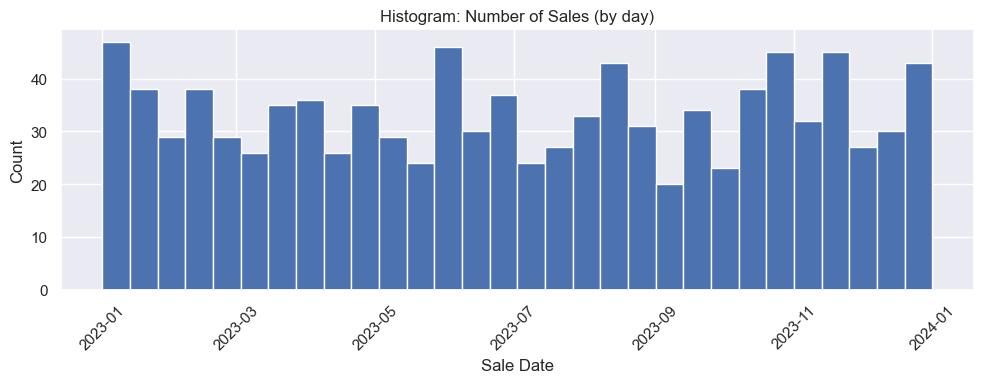

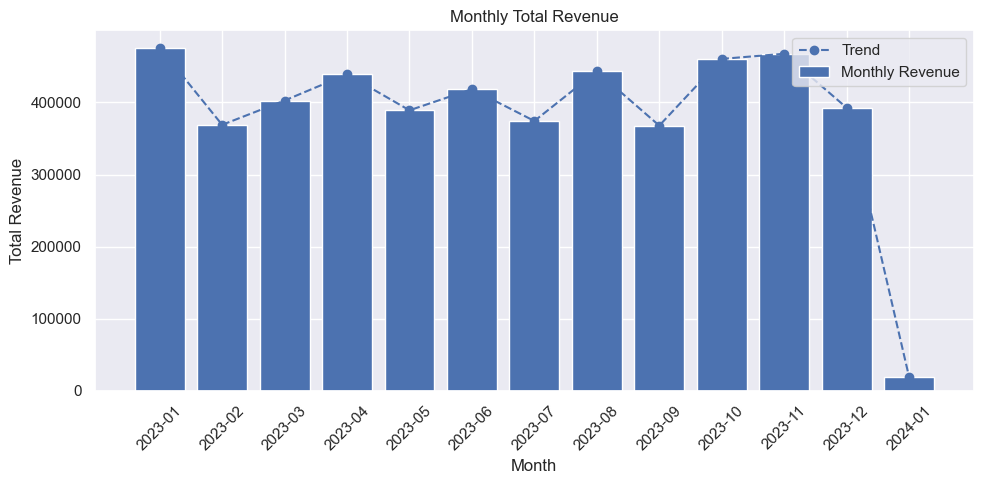

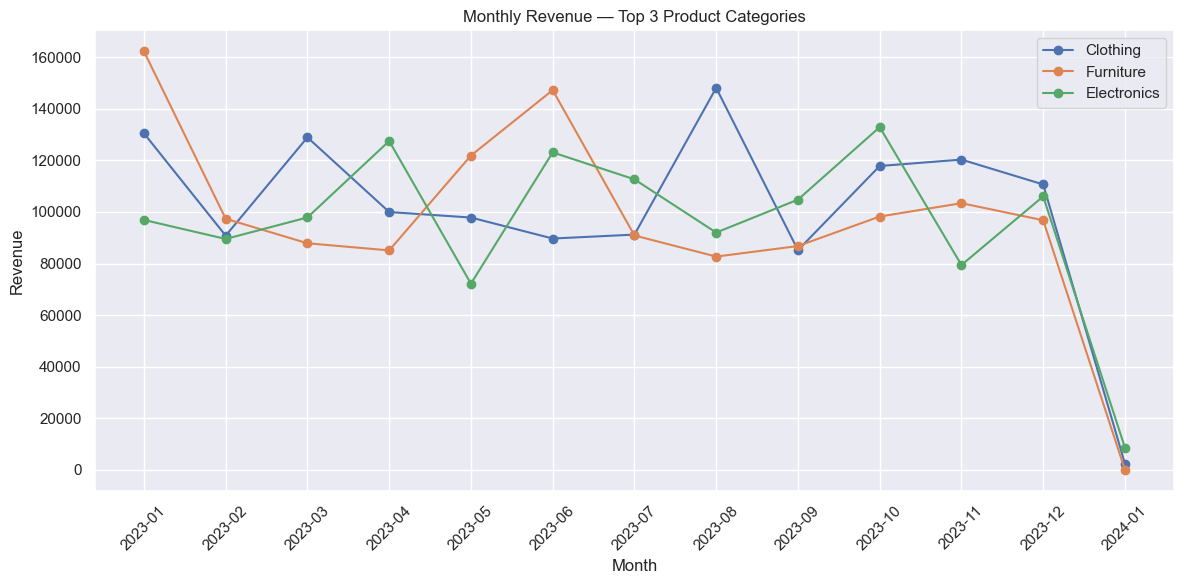

In [19]:
# Minimal time features for plotting
df["Month"] = df["Sale_Date"].dt.to_period("M").astype(str)
df["Month_Num"] = df["Sale_Date"].dt.month
df["Year"] = df["Sale_Date"].dt.year

# Monthly revenue (chronological)
monthly = df.groupby(["Year","Month","Month_Num"]).agg(
    Total_Revenue=("Total_Revenue","sum"),
    Transactions=("Product_ID","count")
).reset_index().sort_values(["Year","Month_Num"])
display(monthly.head(20))
monthly.to_csv("CSV files/monthly_revenue.csv", index=False)

# Plot: histogram of sale dates (counts by day)
plt.figure(figsize=(10,4))
plt.hist(df["Sale_Date"].dt.date, bins=30)
plt.title("Histogram: Number of Sales (by day)")
plt.xlabel("Sale Date")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("CSV files/hist_sales_by_day.png", dpi=150)
plt.show()

# Plot: Monthly Revenue bar + line
plt.figure(figsize=(10,5))
x = monthly["Month"]
y = monthly["Total_Revenue"]
plt.bar(x, y, label="Monthly Revenue")
plt.plot(x, y.values, marker="o", linestyle="--", label="Trend")
plt.title("Monthly Total Revenue")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("CSV files/monthly_revenue_bar_line.png", dpi=150)
plt.show()

# Plot: Monthly revenue by top N categories (if Product_Category exists)
if "Product_Category" in df.columns:
    top_cats = df.groupby("Product_Category")["Total_Revenue"].sum().nlargest(3).index.tolist()
    if top_cats:
        plt.figure(figsize=(12,6))
        for cat in top_cats:
            tmp = df[df["Product_Category"]==cat].groupby("Month").agg(Total_Revenue=("Total_Revenue","sum")).reindex(monthly["Month"], fill_value=0)
            plt.plot(monthly["Month"], tmp["Total_Revenue"], marker='o', label=cat)
        plt.title("Monthly Revenue — Top 3 Product Categories")
        plt.xlabel("Month")
        plt.ylabel("Revenue")
        plt.xticks(rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.savefig("CSV files/monthly_top3_categories.png", dpi=150)
        plt.show()

In [20]:
# -------------------------
# 11. Distributions & outlier detection
# -------------------------

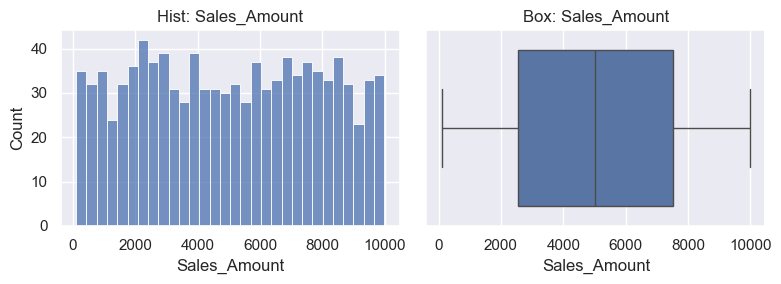

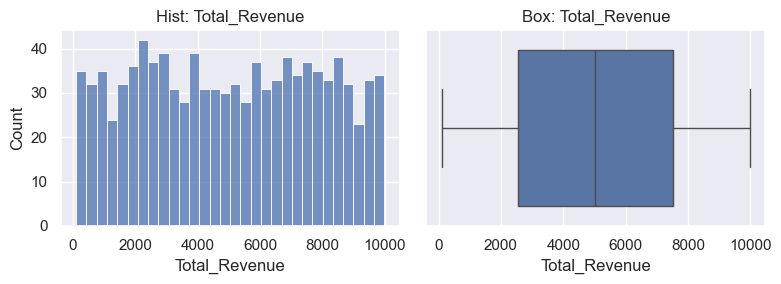

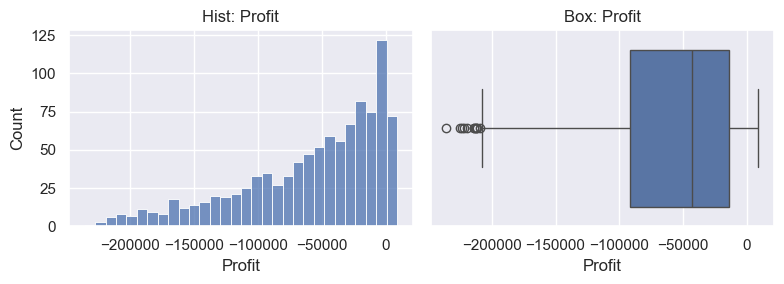

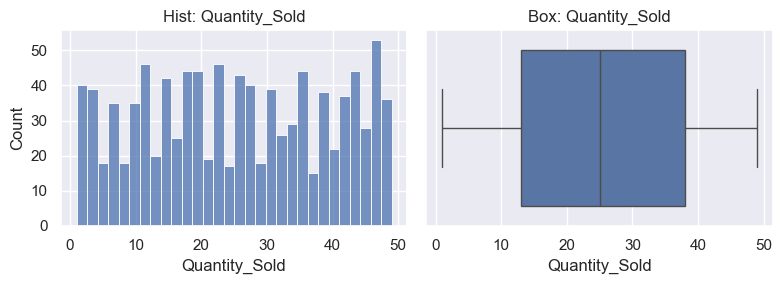

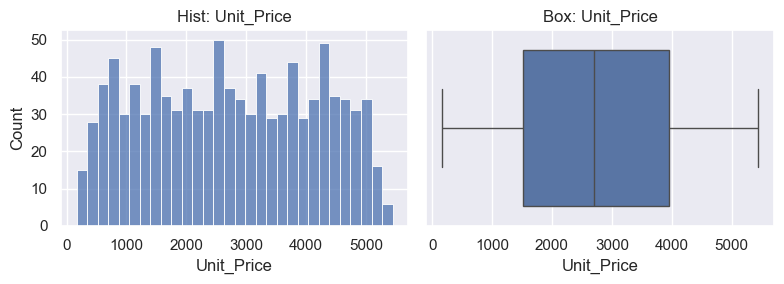

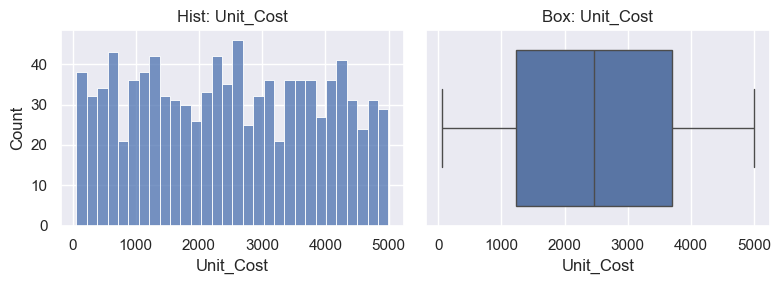

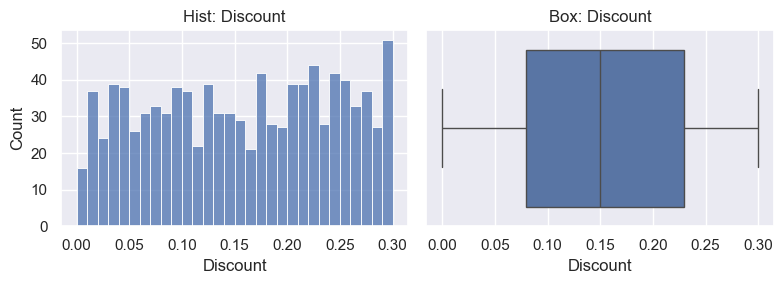

Outliers for Sales_Amount: 0 (lower=-4885.42, upper=14943.17)
Outliers for Profit: 11 (lower=-208817.78, upper=102888.36)
Outliers for Quantity_Sold: 0 (lower=-24.50, upper=75.50)
Outliers for Unit_Price: 0 (lower=-2164.24, upper=7631.30)
Outliers for Unit_Cost: 0 (lower=-2458.35, upper=7399.59)


In [21]:
# Numeric histograms + boxplots
for col in ["Sales_Amount","Total_Revenue","Profit","Quantity_Sold","Unit_Price","Unit_Cost","Discount"]:
    if col in df.columns:
        plt.figure(figsize=(8,3))
        plt.subplot(1,2,1)
        sns.histplot(df[col].dropna(), bins=30, kde=False)
        plt.title(f"Hist: {col}")
        plt.subplot(1,2,2)
        sns.boxplot(x=df[col].dropna())
        plt.title(f"Box: {col}")
        plt.tight_layout()
        plt.savefig("CSV files/dist_{col}.png", dpi=150)
        plt.show()

# IQR outlier detection (report)
outlier_report = {}
for col in ["Sales_Amount","Profit","Quantity_Sold","Unit_Price","Unit_Cost"]:
    if col in df.columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5*iqr
        upper = q3 + 1.5*iqr
        outliers = df[(df[col] < lower) | (df[col] > upper)]
        outlier_report[col] = len(outliers)
        print(f"Outliers for {col}: {len(outliers)} (lower={lower:.2f}, upper={upper:.2f})")

# Save small outlier summary
pd.Series(outlier_report).rename("n_outliers").to_csv("CSV files/outlier_counts.csv")

In [ ]:
# -------------------------
# 12. Correlations & pairwise checks
# -------------------------

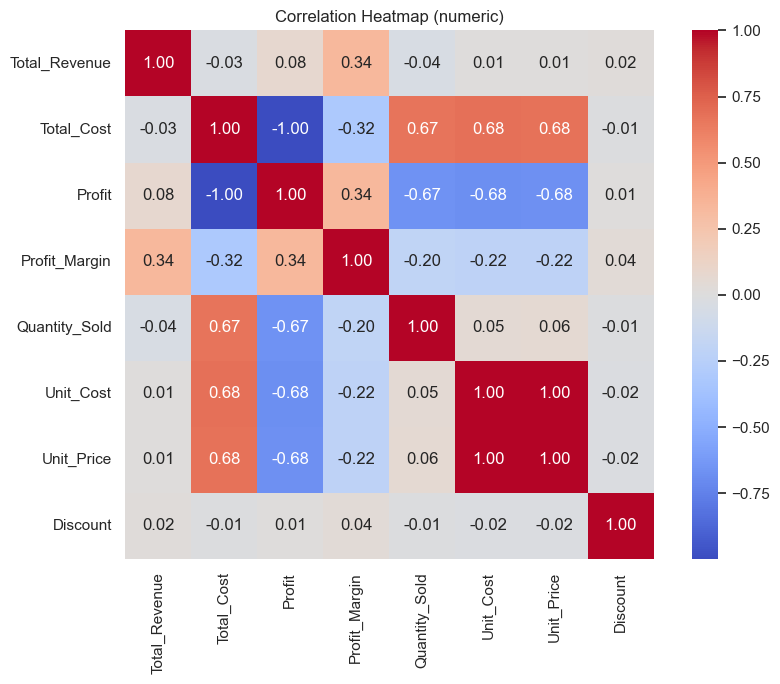

,Total_Revenue,Total_Cost,Profit,Profit_Margin,Quantity_Sold,Unit_Cost,Unit_Price,Discount
Total_Revenue,1.000000,-0.027276,0.078451,0.335003,-0.041599,0.009770,0.011812,0.023153
Total_Cost,-0.027276,1.000000,-0.998687,-0.319126,0.670130,0.682131,0.679205,-0.013336
Profit,0.078451,-0.998687,1.000000,0.335430,-0.670445,-0.679781,-0.676758,0.014487
Profit_Margin,0.335003,-0.319126,0.335430,1.000000,-0.199071,-0.217761,-0.217823,0.035782
Quantity_Sold,-0.041599,0.670130,-0.670445,-0.199071,1.000000,0.053888,0.057296,-0.007806
Unit_Cost,0.009770,0.682131,-0.679781,-0.217761,0.053888,1.000000,0.995056,-0.017741
Unit_Price,0.011812,0.679205,-0.676758,-0.217823,0.057296,0.995056,1.000000,-0.017027
Discount,0.023153,-0.013336,0.014487,0.035782,-0.007806,-0.017741,-0.017027,1.000000


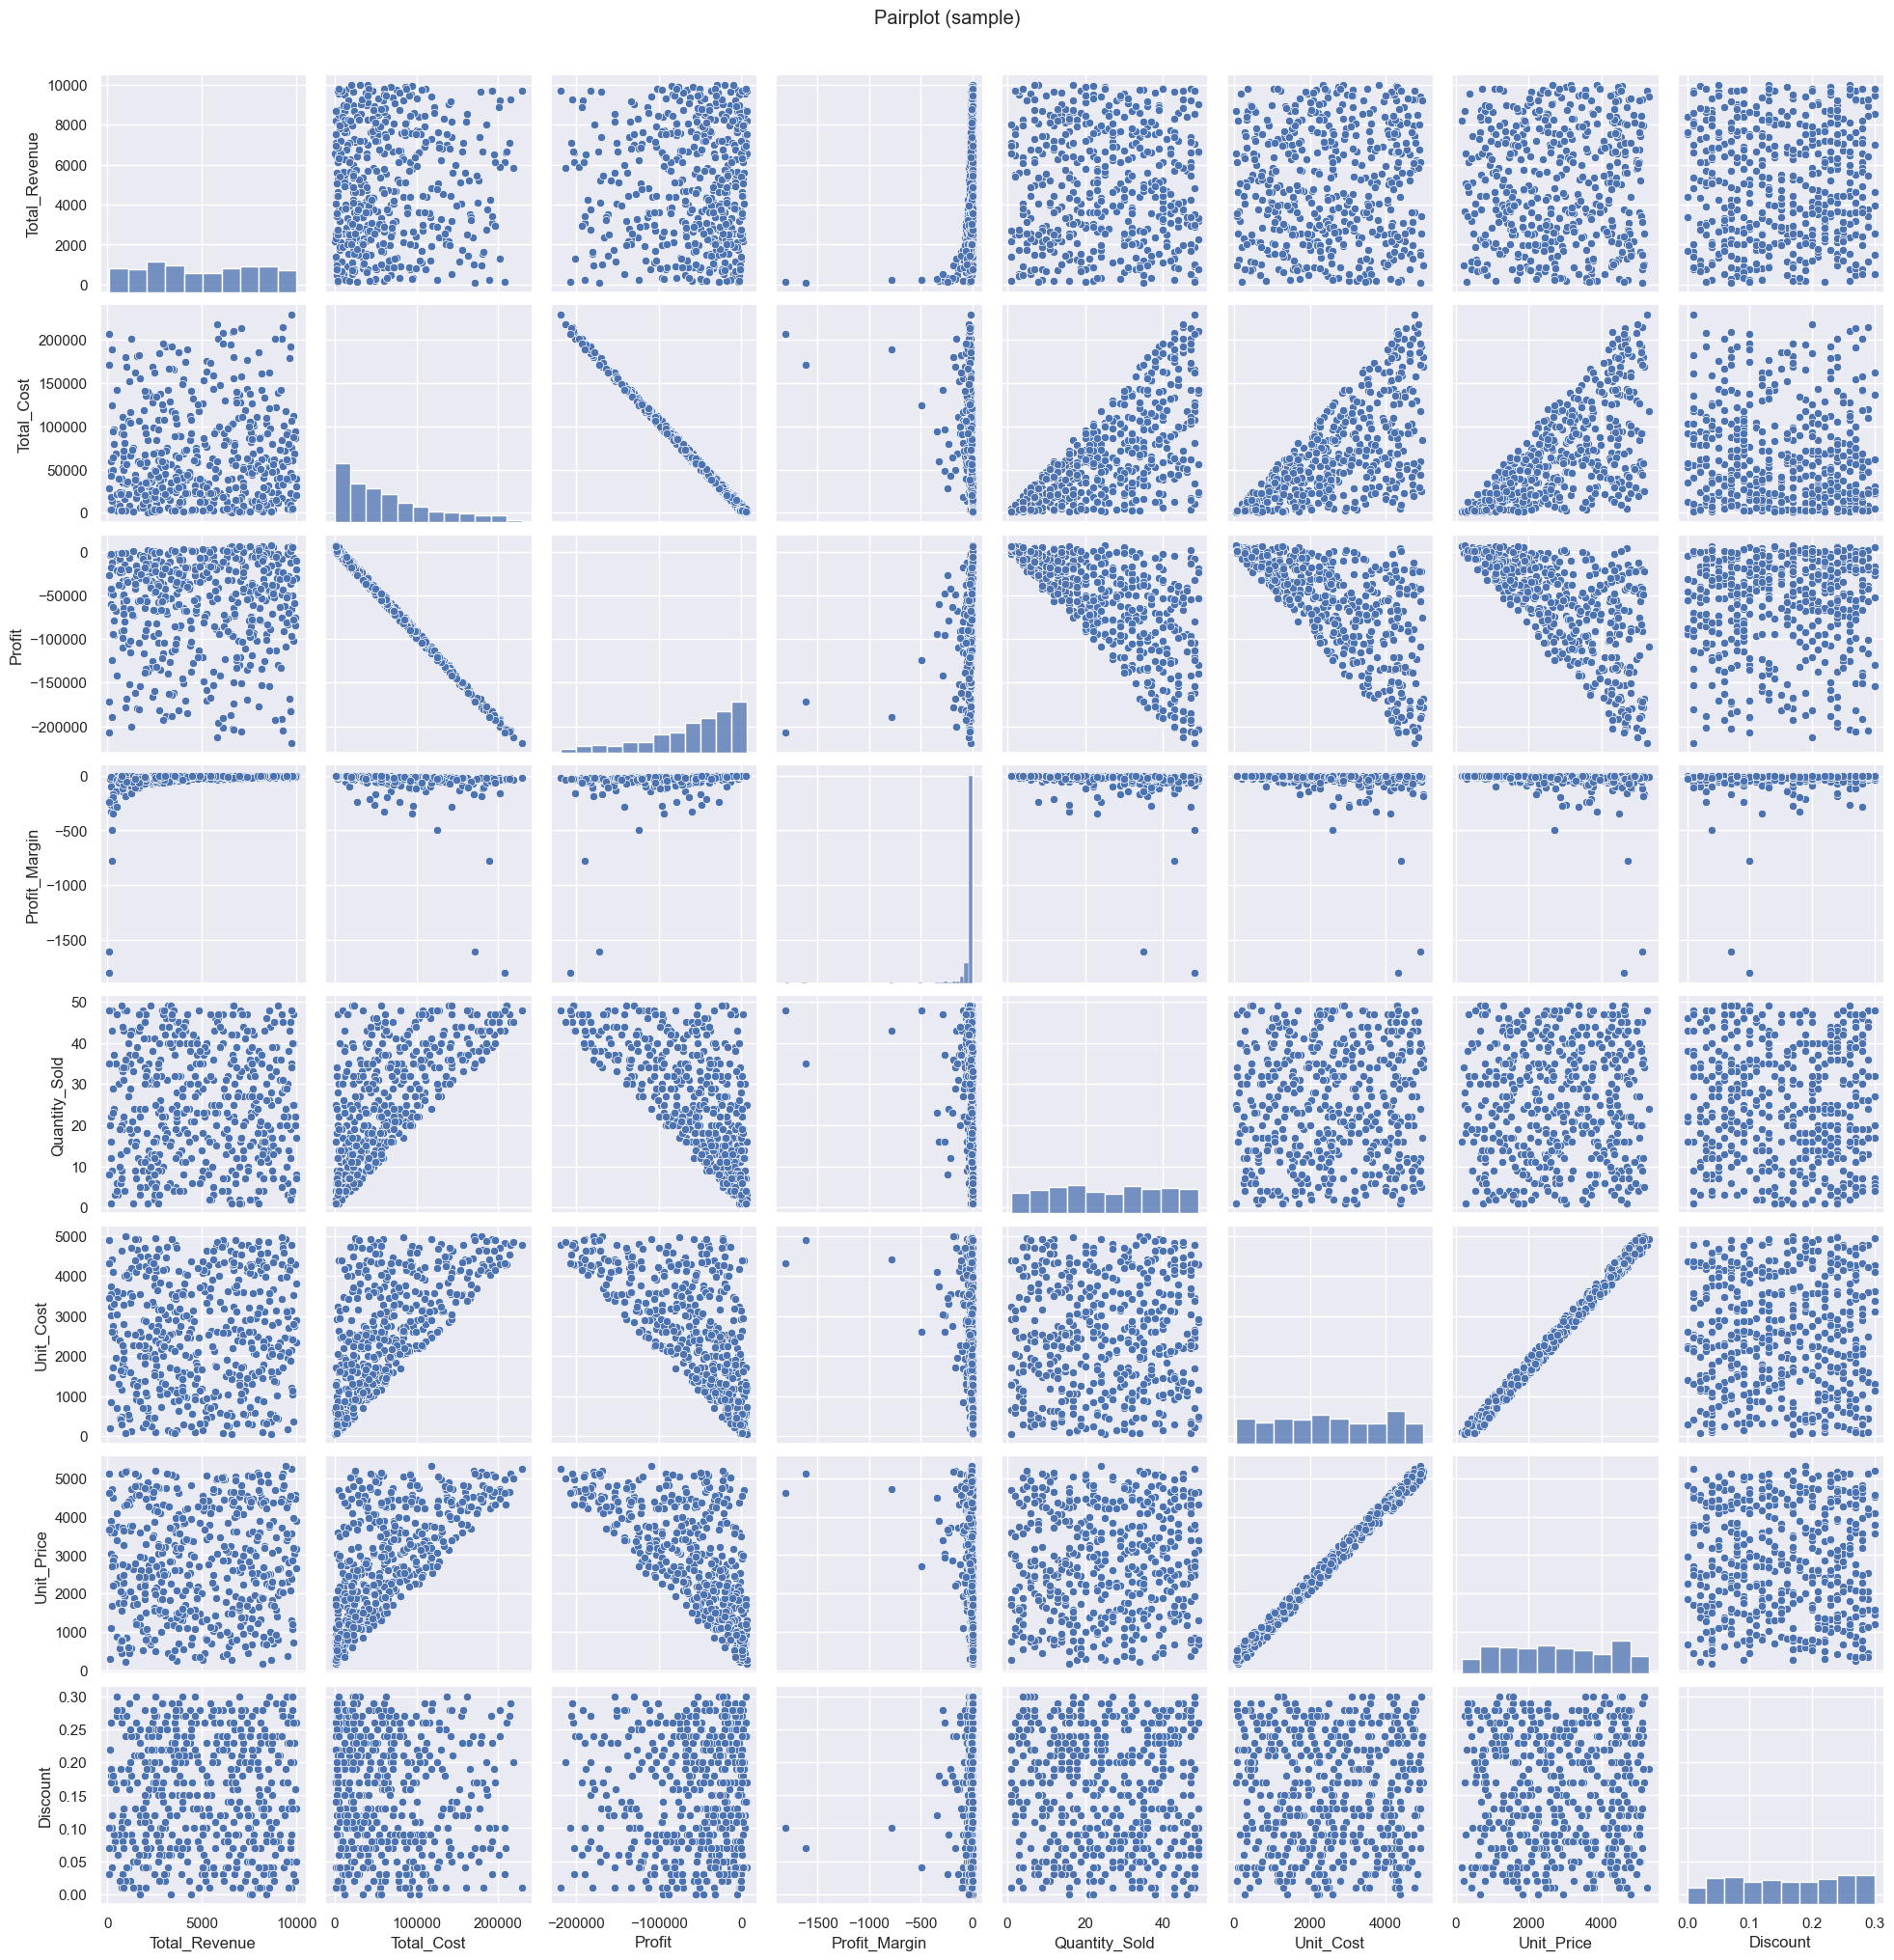

In [30]:
corr_cols = [c for c in ["Total_Revenue","Total_Cost","Profit","Profit_Margin","Quantity_Sold","Unit_Cost","Unit_Price","Discount"] if c in df.columns]
if len(corr_cols) >= 2:
    corr = df[corr_cols].corr()
    plt.figure(figsize=(9,7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
    plt.title("Correlation Heatmap (numeric)")
    plt.tight_layout()
    plt.savefig("CSV files/correlation_heatmap.png", dpi=150)
    plt.show()
    display(corr)

# Pairplot for a small random sample (avoid huge plots)
sample_for_pair = df[corr_cols].dropna().sample(min(500, len(df)))
if len(sample_for_pair.columns) >= 2:
    sns.pairplot(sample_for_pair)
    plt.suptitle("Pairplot (sample)", y=1.02)
    plt.savefig("CSV files/pairplot_sample.png", dpi=150)
    plt.show()

In [ ]:
# -------------------------
# 13. Pivot tables for cross-analysis
# -------------------------

In [32]:
# Region x Category revenue pivot
if {"Region","Product_Category","Total_Revenue"}.issubset(df.columns):
    pivot_rc = pd.pivot_table(df, index="Region", columns="Product_Category", values="Total_Revenue", aggfunc="sum", fill_value=0)
    display(pivot_rc)
    pivot_rc.to_csv("CSV files/pivot_region_category.csv")

# Month x Category revenue pivot
if {"Month","Product_Category","Total_Revenue"}.issubset(df.columns):
    pivot_mc = pd.pivot_table(df, index="Month", columns="Product_Category", values="Total_Revenue", aggfunc="sum", fill_value=0)
    display(pivot_mc.head())
    pivot_mc.to_csv("CSV files/pivot_month_category.csv")

Product_Category,Clothing,Electronics,Food,Furniture
Region,,,,
East,356670.40,303101.42,325864.87,274156.24
North,372977.22,342666.29,258985.65,394983.35
South,269517.74,293663.96,301187.51,289881.65
West,314309.00,304067.97,315735.51,301496.45


Product_Category,Clothing,Electronics,Food,Furniture
Month,,,,
2023-01,130507.06,96903.72,86387.95,162293.63
2023-02,90815.67,89530.85,91206.13,97366.71
2023-03,128934.01,97875.50,87969.27,87859.99
2023-04,99974.35,127514.53,126410.50,85093.23
2023-05,97836.73,72189.35,97178.92,121873.76


In [ ]:
# -------------------------
# 14. Key KPIs snapshot
# -------------------------

In [39]:
kpis = {
    "Total_Revenue": df["Total_Revenue"].sum(),
    "Total_Profit": df["Profit"].sum(),
    "Avg_Profit_Margin": df["Profit_Margin"].mean(),
    "Total_Transactions": len(df),
    "Unique_Products": df["Product_ID"].nunique() if "Product_ID" in df.columns else np.nan,
    "Unique_Sales_Reps": df["Sales_Rep"].nunique() if "Sales_Rep" in df.columns else np.nan
}
print("\nKey KPIs:")
display(pd.Series(kpis))
pd.Series(kpis).to_csv("CSV files/kpis.csv")


Key KPIs:


Total_Revenue         5.019265e+06
Total_Profit         -5.882283e+07
Avg_Profit_Margin    -3.116804e+01
Total_Transactions    1.000000e+03
Unique_Products       1.000000e+02
Unique_Sales_Reps     5.000000e+00
dtype: float64